In [1]:
!pip install rioxarray geopandas cartopy pymannkendall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
import xarray as xr
import geopandas as gpd
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pymannkendall as mk
import numpy as np
from scipy.stats import linregress

Resolution Check

In [4]:
#Resolution Check
pp_raw = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Precipitation/GPCP_2000_2024_Monthly.nc")
print(pp_raw)

lat = pp_raw["lat"].values
lon = pp_raw["lon"].values

lat_res = abs(lat[1] - lat[0])
lon_res = abs(lon[1] - lon[0])


print("Lat resolution ~", lat_res, "degree")
print("Lon resolution ~", lon_res, "degree at equator")

<xarray.Dataset> Size: 3GB
Dimensions:                        (time: 297, lat: 360, lon: 720, bnds: 2)
Coordinates:
  * time                           (time) datetime64[ns] 2kB 2000-01-01 ... 2...
  * lat                            (lat) float32 1kB 89.75 89.25 ... -89.75
  * lon                            (lon) float32 3kB -179.8 -179.2 ... 179.8
Dimensions without coordinates: bnds
Data variables:
    sat_gauge_precip               (time, lat, lon) float32 308MB ...
    sat_gauge_random_error         (time, lat, lon) float32 308MB ...
    sat_gauge_absolute_bias_error  (time, lat, lon) float32 308MB ...
    satellite_precip               (time, lat, lon) float32 308MB ...
    satellite_source               (time, lat, lon) float32 308MB ...
    gauge_precip                   (time, lat, lon) float32 308MB ...
    probability_liquid_phase       (time, lat, lon) float32 308MB ...
    gauge_relative_weight          (time, lat, lon) float32 308MB ...
    quality_index                  (t

Nearest Neighbor Interpolation to 0.25 degree cell

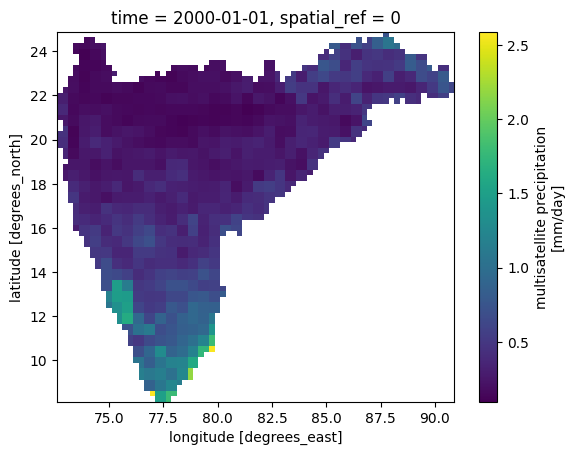

In [6]:
precip = pp_raw["satellite_precip"]
new_lat = np.arange(float(precip.lat.min()), float(precip.lat.max()), 0.25)
new_lon = np.arange(float(precip.lon.min()), float(precip.lon.max()), 0.25)

precip_025 = precip.interp(
    lat=new_lat,
    lon=new_lon,
    method="nearest"
)
precip_025 = precip_025.rio.write_crs("EPSG:4326")
precip_025 = precip_025.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
gdf = gpd.read_file("/content/drive/MyDrive/GNR644 - Water Balance/Data/PeninsularIndia/peninsularIndia_lvl3.shp")
gdf = gdf.to_crs("EPSG:4326")
precip_clip = precip_025.rio.clip(gdf.geometry, gdf.crs, drop=True)
precip_clip.isel(time=0).plot()
#precip_clip.to_netcdf("/content/drive/MyDrive/GNR644 - Water Balance/Data/Precipitation/Rainfall_Resample_Cropped.nc")

Monthly Mean Analysis

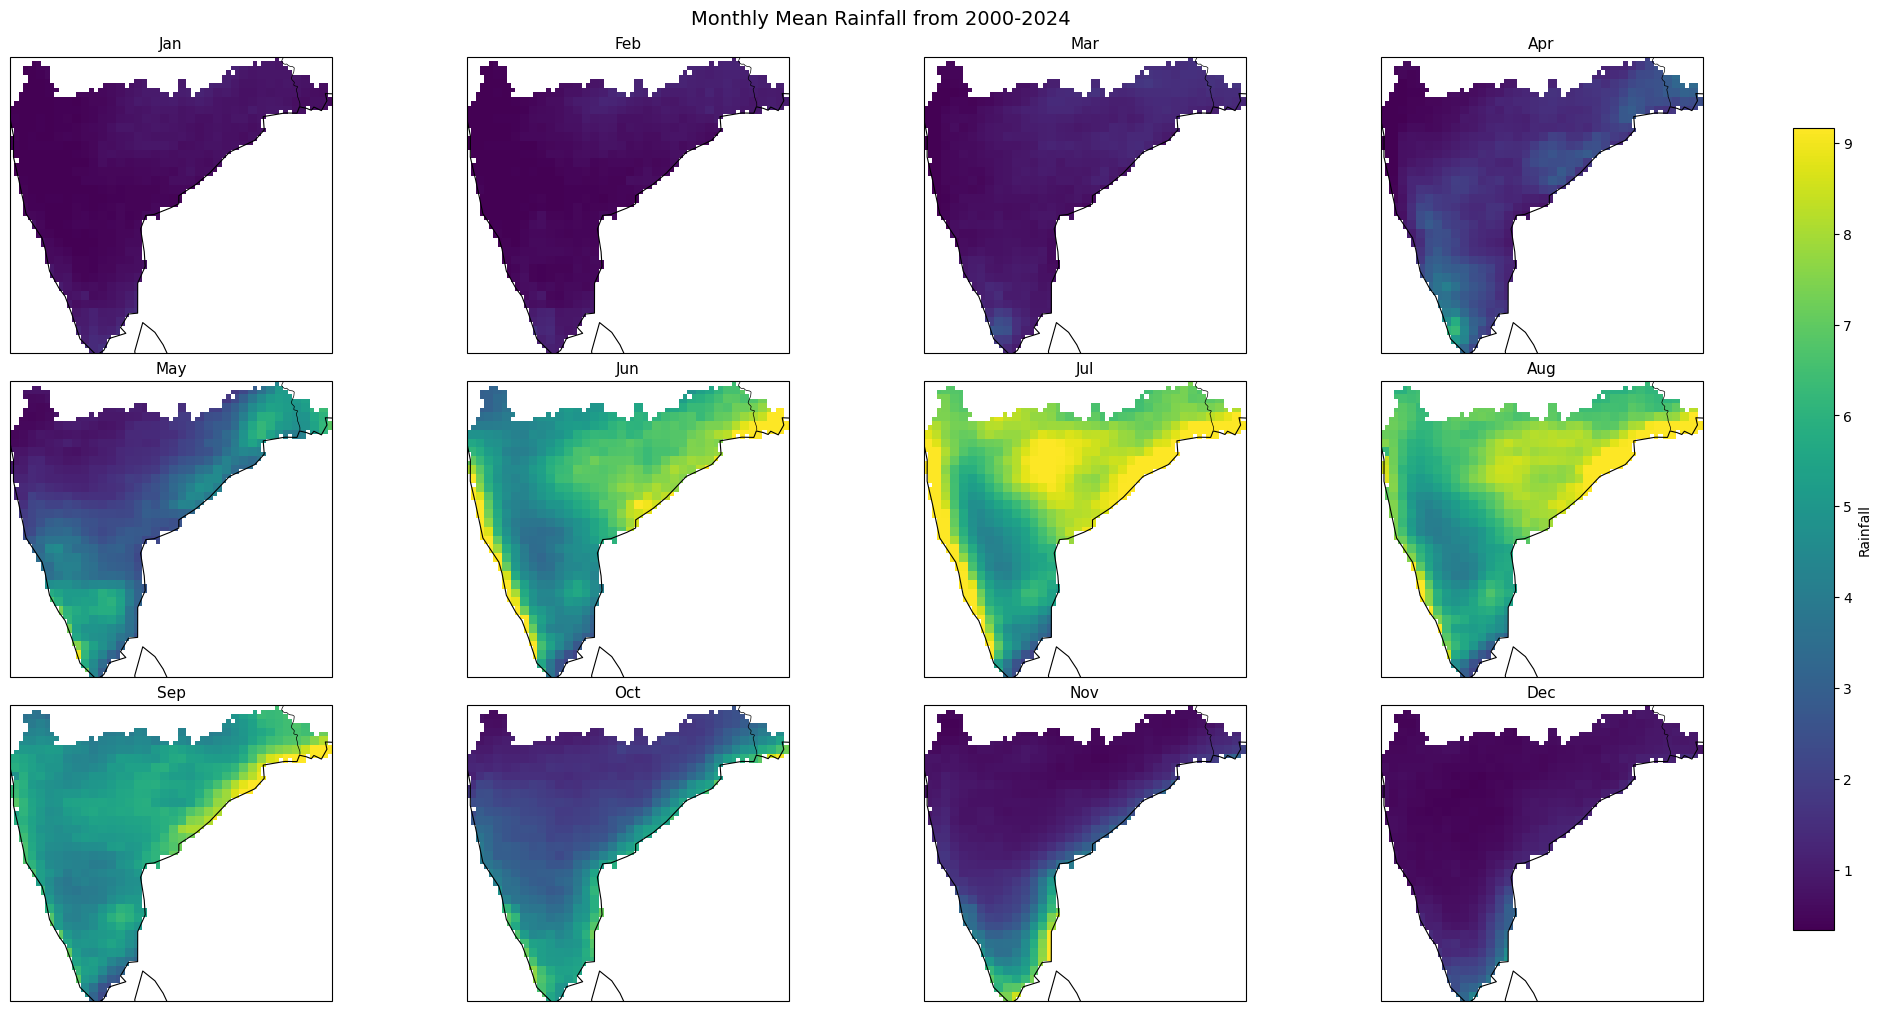

In [8]:
precip_025 = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Precipitation/Rainfall_Resample_Cropped.nc")
rain = precip_025["satellite_precip"]

monthly_mean = rain.groupby("time.month").mean(dim="time")

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

vmin = float(monthly_mean.quantile(0.02))
vmax = float(monthly_mean.quantile(0.98))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(months[i], fontsize=11)

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Rainfall")

plt.suptitle(
    "Monthly Mean Rainfall from 2000-2024",
    fontsize=14
)

plt.show()

Monthly Mann Kendall Trend Analysis

In [9]:


# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
rain_results = {}

for month in range(1, 13):

    # Select monthly rainfall
    rain_m = rain.sel(time=rain["time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        rain_m,
        input_core_dims=[["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    rain_results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })


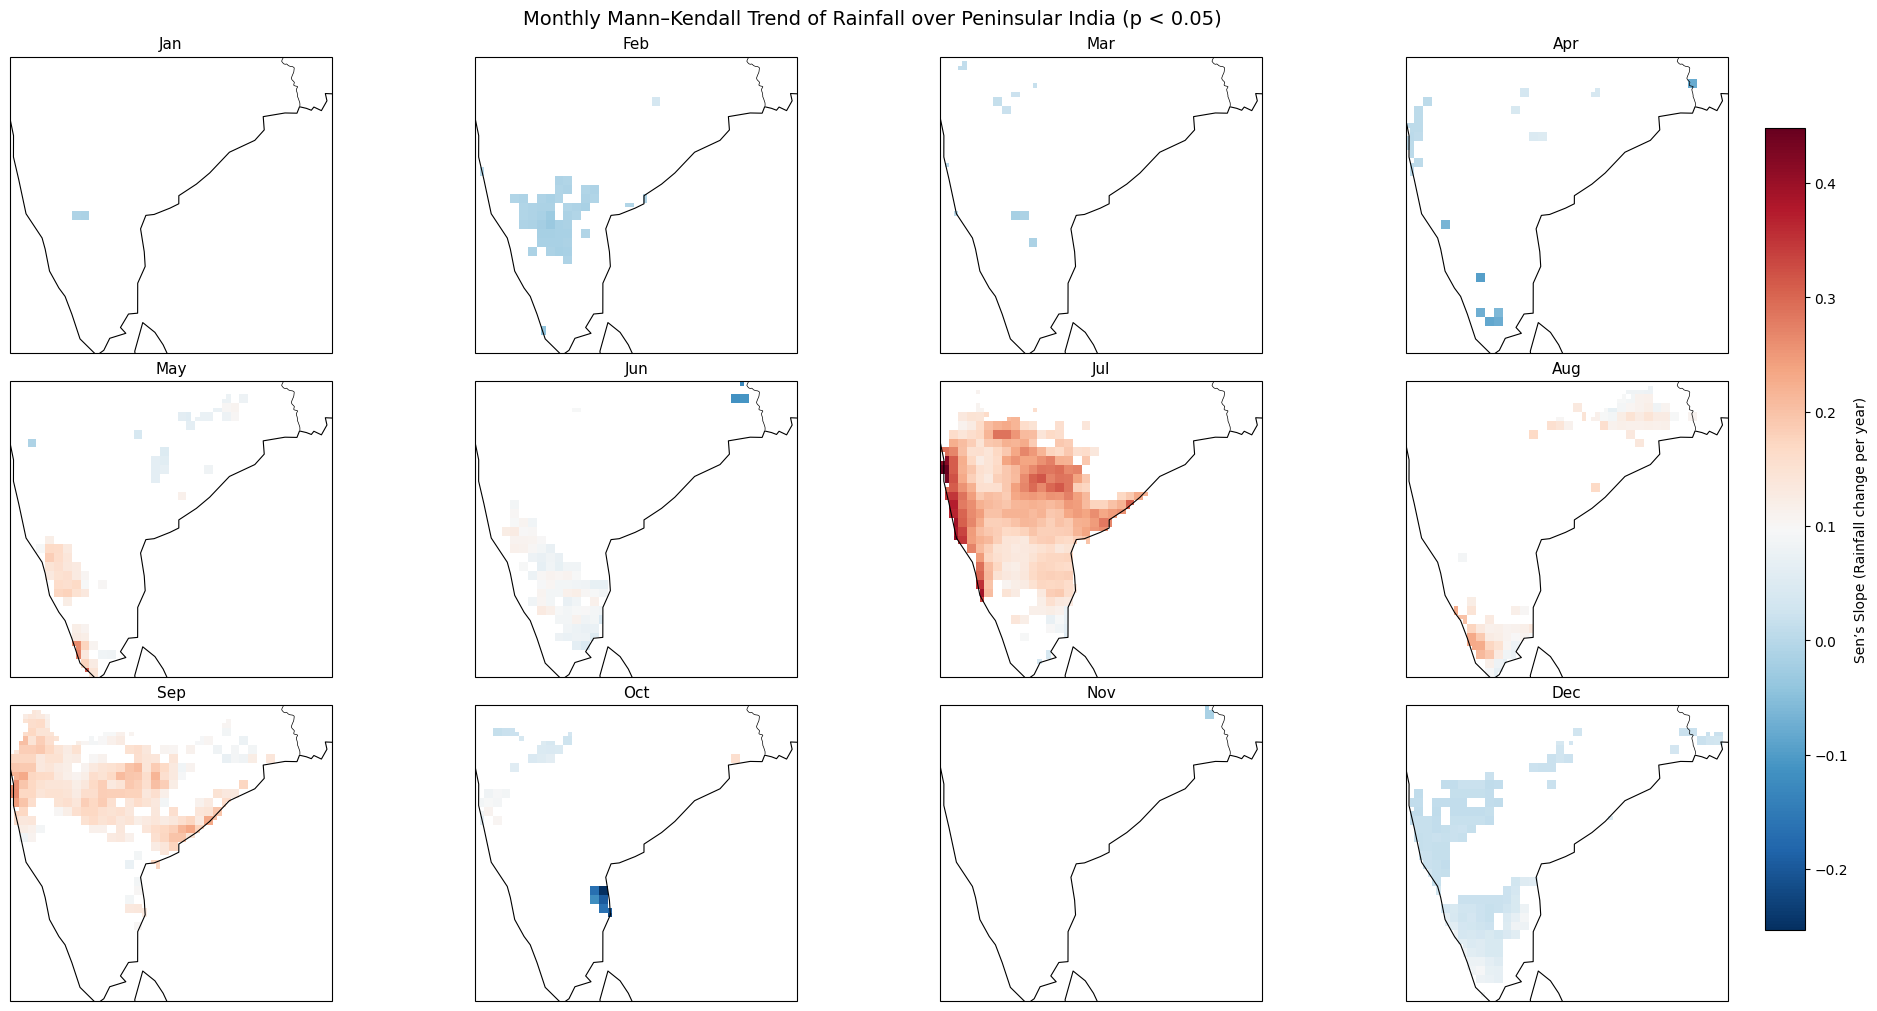

In [10]:
# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (significant rainfall slopes only)
# ---------------------------------
all_rain_slopes = []

for m in range(1, 13):
    rain_slope = rain_results[m]["sens_slope"]
    significant_slope = rain_slope.where(rain_results[m]["p_value"] < 0.05)
    all_rain_slopes.append(significant_slope)

vmin = np.nanmin([s.min().values for s in all_rain_slopes])
vmax = np.nanmax([s.max().values for s in all_rain_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1
    rainfall_mk = rain_results[month]

    significant_slope = rainfall_mk["sens_slope"].where(
        rainfall_mk["p_value"] < 0.05
    )

    im = significant_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional spatial focus
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)

cbar.set_label("Sen’s Slope (Rainfall change per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Rainfall over Peninsular India (p < 0.05)",
    fontsize=14
)

plt.show()


Time Series Graph of Mean

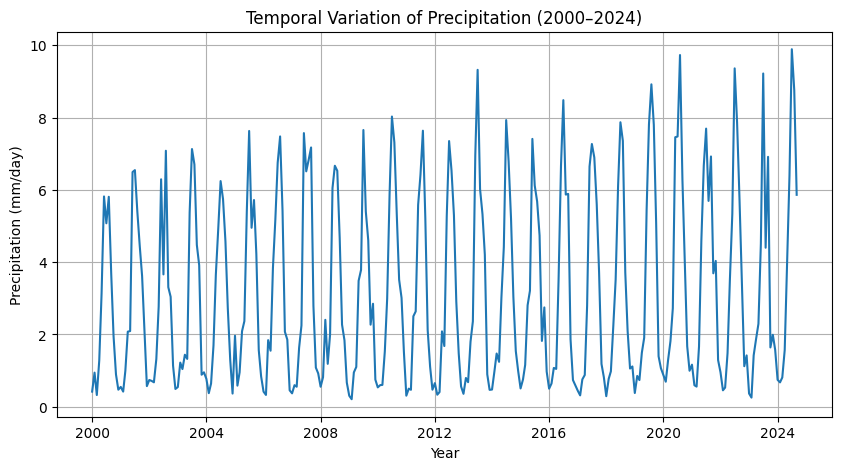

In [11]:
pp_ts = rain.mean(dim=['lat','lon'])
plt.figure(figsize=(10,5))

pp_ts.plot(label='Precipitation')

plt.title("Temporal Variation of Precipitation (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm/day)")
plt.grid(True)

plt.show()

Grouping of Mean by month

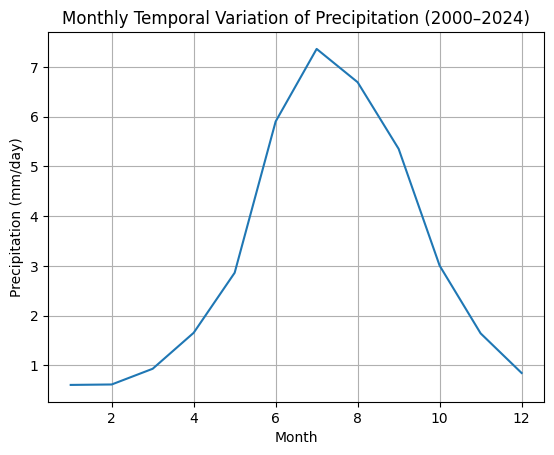

In [12]:
pp_season = pp_ts.groupby('time.month').mean()
pp_season.plot(label='Precipitation')
plt.title("Monthly Temporal Variation of Precipitation (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm/day)")
plt.grid(True)

Trend Analysis

In [13]:
time_pp = np.arange(len(pp_ts))

slope, intercept, r, p, std = linregress(time_pp, pp_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 0.003400847067673111
p-value: 0.050651187592980214


Pixel wise Trend using MK Test (not like previous one where we perfrom MK Test month wise, here we perform MK Test Overall)

In [14]:
def trend_calc(y):
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for Precipitation from 2000 to 2024')

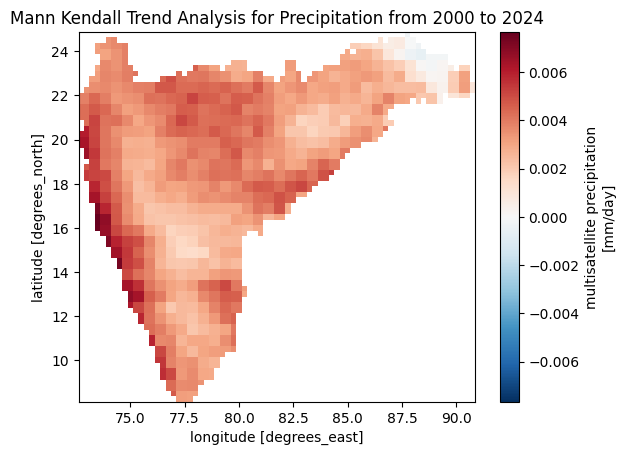

In [16]:
pp_trend = xr.apply_ufunc(
    trend_calc,
    rain,
    input_core_dims=[['time']],
    vectorize=True
)

pp_trend.plot()
plt.title("Mann Kendall Trend Analysis for Precipitation from 2000 to 2024")

Anomaly to find Drought years

Text(0.5, 1.0, 'Anomaly TSA Plot for Precipitation')

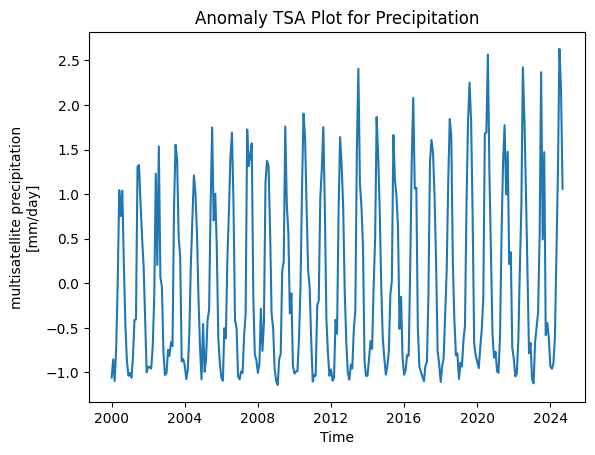

In [17]:
pp_mean = pp_ts.mean()
pp_std = pp_ts.std()
pp_anomaly = pp_ts - pp_mean
pp_std_anomaly = (pp_ts - pp_mean) / pp_std
pp_std_anomaly.plot()
plt.title("Anomaly TSA Plot for Precipitation")